
# Garded Activity[5 marks ]: Working with Categorical Data

This notebook is designed for students learning data preprocessing and categorical data handling in Machine Learning and Data Science.

## Learning Objectives
By the end of this notebook, students will be able to:

- Identify categorical features
- Understand nominal vs ordinal categories
- Perform encoding techniques
- Handle missing values
- Apply preprocessing pipelines
- Work with real-world datasets
- Evaluate preprocessing impact on ML models

## Real-World Scenarios Included
1. Employee Attrition
2. Online Retail Customer Segmentation
3. Healthcare Insurance Prediction
4. Student Performance Analysis



# Import Libraries

.


In [1]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt



# Scenario 1: Employee Attrition Dataset

A company wants to predict whether employees are likely to leave the organization.

## Dataset Columns
- Gender
- Department
- EducationLevel
- JobRole
- MonthlyIncome
- Attrition

## Task
1. Identify categorical variables
2. Separate nominal and ordinal features
3. Apply suitable encoding techniques


In [2]:

employee_data = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male'],
    'Department': ['HR', 'IT', 'Finance', 'IT', 'HR', 'Finance'],
    'EducationLevel': ['Bachelor', 'Master', 'PhD', 'Bachelor', 'Master', 'PhD'],
    'JobRole': ['Manager', 'Developer', 'Analyst', 'Developer', 'Manager', 'Analyst'],
    'MonthlyIncome': [5000, 7000, 6500, 7200, 5100, 6800],
    'Attrition': ['Yes', 'No', 'No', 'No', 'Yes', 'No']
})

employee_data


,Gender,Department,EducationLevel,JobRole,MonthlyIncome,Attrition
0,Male,HR,Bachelor,Manager,5000,Yes
1,Female,IT,Master,Developer,7000,No
2,Female,Finance,PhD,Analyst,6500,No
3,Male,IT,Bachelor,Developer,7200,No
4,Female,HR,Master,Manager,5100,Yes
5,Male,Finance,PhD,Analyst,6800,No



# Exercise 1

## Questions
1. Which columns are categorical?
2. Which categorical columns are ordinal?
3. Why is `EducationLevel` considered ordinal?

Write your answers below.


In [4]:
employee_data.dtypes #Identify data types of each column
#Looks like gender, department, education level, job role, and attrition are categorical variables, while monthly income is numerical.
categorical_cols = ['Gender', 'Department', 'EducationLevel', 'JobRole', 'Attrition']

for col in categorical_cols:
    print(f"\n{col}:")
    print(employee_data[col].unique())


Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Department:
<StringArray>
['HR', 'IT', 'Finance']
Length: 3, dtype: str

EducationLevel:
<StringArray>
['Bachelor', 'Master', 'PhD']
Length: 3, dtype: str

JobRole:
<StringArray>
['Manager', 'Developer', 'Analyst']
Length: 3, dtype: str

Attrition:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


### Question1: Categorical Columns:
Gender
Department
EducationLevel
JobRole
Attrition

### Question2&3: Ordinal Column:EducationLevel
Reason:
EducationLevel is ordinal because the categories have a meaningful ranking (e.g., Bachelor's < Master's < PhD). The other categorical variables are nominal because their categories do not have a natural order.


# Label Encoding vs One-Hot Encoding

## Label Encoding
Used mainly for ordinal categories.

## One-Hot Encoding
Used mainly for nominal categories.

### Example


In [5]:

# Ordinal Encoding for EducationLevel

education_order = [['Bachelor', 'Master', 'PhD']]

ordinal_encoder = OrdinalEncoder(categories=education_order)

employee_data['EducationLevel_Encoded'] = ordinal_encoder.fit_transform(
    employee_data[['EducationLevel']]
)

# One-Hot Encoding for Department

one_hot = pd.get_dummies(employee_data['Department'], prefix='Dept')

employee_encoded = pd.concat([employee_data, one_hot], axis=1)

employee_encoded


,Gender,Department,EducationLevel,JobRole,MonthlyIncome,Attrition,EducationLevel_Encoded,Dept_Finance,Dept_HR,Dept_IT
0,Male,HR,Bachelor,Manager,5000,Yes,0.0,False,True,False
1,Female,IT,Master,Developer,7000,No,1.0,False,False,True
2,Female,Finance,PhD,Analyst,6500,No,2.0,True,False,False
3,Male,IT,Bachelor,Developer,7200,No,0.0,False,False,True
4,Female,HR,Master,Manager,5100,Yes,1.0,False,True,False
5,Male,Finance,PhD,Analyst,6800,No,2.0,True,False,False



# Scenario 2: Missing Values in Categorical Data

Real-world datasets often contain missing values.

## Common Strategies
- Most frequent value
- Constant replacement
- Create new category

### Example


In [6]:

customer_data = pd.DataFrame({
    'City': ['Toronto', 'Ottawa', np.nan, 'Montreal', 'Toronto', np.nan],
    'SubscriptionType': ['Basic', 'Premium', 'Basic', np.nan, 'Premium', 'Basic']
})

customer_data


,City,SubscriptionType
0,Toronto,Basic
1,Ottawa,Premium
2,NaN,Basic
3,Montreal,NaN
4,Toronto,Premium
5,NaN,Basic


In [9]:

# Handle missing categorical values

imputer = SimpleImputer(strategy='most_frequent')

customer_data_imputed = pd.DataFrame(
    imputer.fit_transform(customer_data),
    columns=customer_data.columns
)

customer_data_imputed


,City,SubscriptionType
0,Toronto,Basic
1,Ottawa,Premium
2,Toronto,Basic
3,Montreal,Basic
4,Toronto,Premium
5,Toronto,Basic



# Exercise 2

## Try These Tasks
1. Replace missing values using `constant`
2. Create a new category called `"Unknown"`
3. Compare results with `most_frequent`


In [ ]:
from sklearn.impute import SimpleImputer

#replace missing value with constant value 'Unknown'
constant_imputer = SimpleImputer(
    strategy='constant',
    fill_value='Unknown'
)

customer_data_constant = pd.DataFrame(
    constant_imputer.fit_transform(customer_data),
    columns=customer_data.columns
)

customer_data_constant

,City,SubscriptionType
0,Toronto,Basic
1,Ottawa,Premium
2,Unknown,Basic
3,Montreal,Unknown
4,Toronto,Premium
5,Unknown,Basic


### 3 Compare the result with most_frequent: 
#### The most_frequent method fills missing values with the category that appears the most in the dataset. This is useful because it removes missing values quickly, but it may not always be accurate since we are assuming the missing value belongs to the most common category.
#### The constant method creates a new category such as "Unknown" for missing values. This keeps the information that the data was originally missing instead of making a guess. I think this method can be more useful when the missing values might have some meaning or when we do not want to assume a category and better for the model to detect any patterns in real data.

#### Overall, most_frequent is simpler, while "Unknown" helps preserve information about missing data.


# Scenario 3: Building a Preprocessing Pipeline

Pipelines help automate preprocessing.

## Real-World Use Case
Healthcare insurance premium prediction.


In [11]:

insurance_data = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male'],
    'Smoker': ['Yes', 'No', 'No', 'Yes', 'No', 'Yes'],
    'Region': ['North', 'South', 'East', 'West', 'North', 'South'],
    'Age': [25, 45, 33, 52, 28, 40],
    'PremiumCategory': [1, 0, 0, 1, 0, 1]
})

insurance_data


,Gender,Smoker,Region,Age,PremiumCategory
0,Male,Yes,North,25,1
1,Female,No,South,45,0
2,Female,No,East,33,0
3,Male,Yes,West,52,1
4,Female,No,North,28,0
5,Male,Yes,South,40,1


In [12]:

X = insurance_data.drop('PremiumCategory', axis=1)
y = insurance_data['PremiumCategory']

categorical_features = ['Gender', 'Smoker', 'Region']
numeric_features = ['Age']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_pipeline.fit(X_train, y_train)

predictions = model_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))


Accuracy: 0.5



# Scenario 4: High Cardinality Categorical Features

Some columns may contain too many unique values.

## Examples
- Postal Codes
- Product IDs
- User IDs

## Problems
- Too many dimensions after encoding
- Increased memory usage
- Overfitting

## Common Solutions
- Frequency Encoding
- Target Encoding
- Hash Encoding


In [13]:

product_data = pd.DataFrame({
    'ProductID': [
        'P1001', 'P1002', 'P1003',
        'P1004', 'P1005', 'P1006'
    ]
})

frequency_encoding = product_data['ProductID'].value_counts().to_dict()

product_data['FrequencyEncoded'] = product_data['ProductID'].map(
    frequency_encoding
)

product_data


,ProductID,FrequencyEncoded
0,P1001,1
1,P1002,1
2,P1003,1
3,P1004,1
4,P1005,1
5,P1006,1



# Visualizing Categorical Data

Bar charts are commonly used for categorical variables.


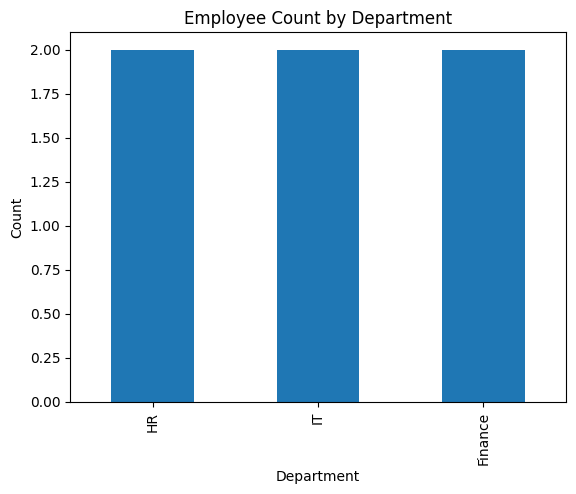

In [14]:

employee_data['Department'].value_counts().plot(kind='bar')

plt.title('Employee Count by Department')
plt.xlabel('Department')
plt.ylabel('Count')

plt.show()




## Discussion Questions
1. When should we use One-Hot Encoding?
2. Why can Label Encoding be dangerous for nominal data?
3. What preprocessing issues occur in production systems?
4. How do unseen categories affect ML pipelines?


### 1. When should we use One-Hot Encoding?
#### One-Hot Encoding should be used for nominal categorical variables that have a small number of unique categories, such as Gender, Department, or Region.
### 2. Why can Label Encoding be dangerous for nominal data?
#### Label Encoding assigns numbers to categories, which may create a false order between categories. For example, assigning HR=0, IT=1, and Finance=2 may incorrectly imply that Finance is greater than IT or HR.
### 3. What preprocessing issues occur in production systems?
#### Common issues include missing values, unseen categories, inconsistent data formats, data entry errors, and changes in data over time. These issues can affect model performance if not handled properly
### 4. How do unseen categories affect ML pipelines?
#### Unseen categories are values that were not present during training. They can cause errors during encoding. Using techniques such as OneHotEncoder(handle_unknown='ignore') helps prevent pipeline failures when new categories appear.



# Mini Project

## Build a Customer Churn Prediction Pipeline

### Tasks
1. Create your own dataset
2. Add:
   - Missing values
   - Ordinal features
   - Nominal features
3. Build preprocessing pipeline
4. Train classification model
5. Evaluate performance
6. Explain preprocessing choices


In [20]:
#import libraries for model building and evaluation
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#Create youw own dataset: Using Randomseed for it and add numeric, ornial and nominal features.
np.random.seed(42)
n = 300

df = pd.DataFrame({
    # Numeric features
    "age":             np.random.randint(18, 70, n).astype(float),
    "monthly_charges": np.random.uniform(20, 120, n),
    "tenure_months":   np.random.randint(1, 72, n).astype(float),

    # Ordinal feature (has a natural order)
    "satisfaction":    np.random.choice(["Low", "Medium", "High"], n),

    # Nominal features (no natural order)
    "contract_type":   np.random.choice(["Month-to-Month", "One Year", "Two Year"], n),
    "payment_method":  np.random.choice(["Credit Card", "Bank Transfer", "Mailed Check"], n),

    # Target
    "churn":           np.random.choice([0, 1], n, p=[0.75, 0.25])
})

#2: Add missing values, randomly.
df.loc[np.random.choice(df.index, 30, replace=False), "age"] = np.nan
df.loc[np.random.choice(df.index, 25, replace=False), "satisfaction"] = np.nan
df.loc[np.random.choice(df.index, 20, replace=False), "payment_method"] = np.nan

#Visualize the dataset and check for missing values.
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

Dataset shape: (300, 7)

Missing values:
 age                30
monthly_charges     0
tenure_months       0
satisfaction       25
contract_type       0
payment_method     20
churn               0
dtype: int64

First 5 rows:
     age  monthly_charges  tenure_months satisfaction   contract_type  \
0  56.0       108.263634           36.0          Low        One Year   
1  69.0        38.870711            8.0       Medium  Month-to-Month   
2   NaN        47.887135           58.0          Low  Month-to-Month   
3  32.0        90.035783           60.0          Low        One Year   
4  60.0       104.666114           50.0          Low  Month-to-Month   

  payment_method  churn  
0    Credit Card      0  
1    Credit Card      0  
2  Bank Transfer      1  
3   Mailed Check      0  
4            NaN      1  


In [21]:
#define features
from sklearn.metrics import confusion_matrix


numeric_features  = ["age", "monthly_charges", "tenure_months"]
ordinal_features  = ["satisfaction"]          # Low < Medium < High
nominal_features  = ["contract_type", "payment_method"]

X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#3: Build preprocessing pipelines for each feature type.

# Numeric: fill missing with median, then scale.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Ordinal: fill missing with most frequent, encode with order preserved.
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[["Low", "Medium", "High"]]))
])

# Nominal: fill missing with "Unknown", one-hot encode.
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine all pipelines.
preprocessor = ColumnTransformer([
    ("numeric",  numeric_pipeline,  numeric_features),
    ("ordinal",  ordinal_pipeline,  ordinal_features),
    ("nominal",  nominal_pipeline,  nominal_features),
])

#4: Train Model and Predict.
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

model_pipeline.fit(X_train, y_train)

predictions = model_pipeline.predict(X_test)

#Evaluate model performance.
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.75


### Preprocessing Choices Explained:
### First, lets understand the dataset, it is a Customer churn dataset of a telecom company with 300 fictional customers and their details like 'age', how long have they been with the company 'tenure',how much they pay per month or based on what their subscription contract is 'monthly_charges','contract_type'. It also includes financial details like 'payment_method' and finally we have information about their 'satisfaction_level' and most imporantly 'churn' which tells us whether the customer stayed or left. 
### To make it realistic we also added missing values in the dataset.
### Overall, the goal of the model we are trying to create is to use all that customer information to 'predict' who is likely to leave before they actually do.


### Now lets understand preprocessing choices: 
### For Numeric data which is age, monthly_charges and tenure_months, we used median to replace missing values , and not mean to account for any extreme outliers which would create a false middle value if mean is used.Then I scaled the numeric values so that age and monthly_charges dont confuse the model that one of them matters more because the values are higher. 
### For ordinal values like satisfaction_level, I used most_frequent instead of unknown because I am assuming most people agree with the quality of our service so which ever value is most common, we replace missing with that satisfaction score.I also did ordinal encoding, so that we can have numbers for the model instead of text in satusfaction_level and I chose ordinal because each level has a meaning and there is a normal order to this field. 
### For Nominal data like contract_type and payment_method , I replaced missing values with Unknown because it is very customer specic and we cannot just chose a most commonly occuring value to fill it. and then I chose one-hot encoding for it because it has no natural order of arrangement.




# Summary

In this notebook, students practiced:

- Identifying categorical variables
- Ordinal vs nominal data
- Encoding strategies
- Handling missing values
- Building preprocessing pipelines
- Working with real-world scenarios
- Visualizing categorical data


## Show the demo to get marks - 5%